# Merge article and market features

This notebook joins the final article-level text features with the market feature table on `article_id`, and then checks that the relationship between sentiment and post-publication abnormal return looks sensible.

The goal is to catch issues early: missing joins, duplicate IDs, sign mismatches, and suspicious feature relationships should all be visible in this merged table before the model is trained.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from stock_predictor.config import PROCESSED_DATA_DIR

print("Ready to merge article and market tables.")

2026-08-24 19:32:11.526 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


Ready to merge article and market tables.


## 1) Load the final tables

We use the already-generated feature outputs:

- `pipeline_run/article_features.parquet` for the final article sentiment and text features
- `market_features.parquet` for the event-study and market-context features

The merge key is `article_id`, which is the common identifier across the text and market layers.

The row counts are close (1,976 vs 1,973) but that closeness is misleading: the ID *sets* diverge far more than the counts suggest, an inner join only keeps 1,828 rows. Section 1a investigates why before we accept the intersection as the model table.

In [2]:
articles = pd.read_parquet(PROCESSED_DATA_DIR / "pipeline_run" / "article_features.parquet")
market = pd.read_parquet(PROCESSED_DATA_DIR / "market_features.parquet")

print(f"Article features rows: {len(articles)}")
print(f"Market features rows: {len(market)}")
print(f"Unique article IDs in text: {articles['article_id'].nunique()}")
print(f"Unique article IDs in market: {market['article_id'].nunique()}")

merged = articles.merge(
    market,
    on="article_id",
    how="inner",
    validate="one_to_one",
    suffixes=("_article", "_market"),
)

print(f"Merged rows: {len(merged)}")
print(merged[["article_id", "timestamp_utc", "source", "fus_conf_graft_floor_mean", "abnormal_return_1d"]].head().to_string(index=False))

Article features rows: 1976
Market features rows: 1973
Unique article IDs in text: 1976
Unique article IDs in market: 1973
Merged rows: 1828
 article_id             timestamp_utc   source  fus_conf_graft_floor_mean  abnormal_return_1d
  138796882 2025-08-22 08:13:15+00:00 Benzinga                   0.406216            0.046809
  136476320 2025-08-22 10:40:18+00:00    Yahoo                  -0.034478            0.046809
  136476576 2025-08-22 10:48:06+00:00    Yahoo                  -0.700990            0.046809
  138802535 2025-08-22 11:10:13+00:00 Benzinga                  -0.337289            0.023783
  136476575 2025-08-22 11:31:03+00:00    Yahoo                  -0.738242            0.046809


## 1a) Why the ID sets don't match

1,976 article IDs and 1,973 market IDs, but only 1,828 join. That means 148 article-side IDs and 145 market-side IDs have no partner at all — far more disagreement than the row counts imply. Two candidate explanations:

1. Legitimate filtering — e.g. the market layer drops articles with no tradable price data, or the text layer drops irrelevant articles.
2. The two tables were built from different snapshots of the article corpus.

We check both by loading the corpus each pipeline actually reads from and testing whether each feature table's IDs are a subset of it.

In [3]:
from stock_predictor.config import INTERIM_DATA_DIR

article_ids = set(articles["article_id"])
market_ids = set(market["article_id"])
only_article = article_ids - market_ids
only_market = market_ids - article_ids

print(f"IDs only in article_features : {len(only_article)}")
print(f"IDs only in market_features   : {len(only_market)}")

# market_features.parquet is built (notebook market/1.4) directly from this file.
market_source = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
market_source_ids = set(market_source["article_id"])

print(f"\ndata/processed/processed_articles.parquet: {len(market_source_ids)} article IDs")
print(f"market_features IDs subset of it?   {market_ids <= market_source_ids} "
      f"({len(market_ids - market_source_ids)} not found)")
print(f"article_features IDs subset of it?  {article_ids <= market_source_ids} "
      f"({len(article_ids - market_source_ids)} not found)")

# article_features.parquet is built (stock_predictor.text.run_pipeline) from a *different*
# path: config.PROCESSED_ARTICLES_PATH, which points at data/interim/, not data/processed/.
interim_path = INTERIM_DATA_DIR / "processed_articles.parquet"
print(f"\ntext pipeline's source, {interim_path}, exists: {interim_path.exists()}")

IDs only in article_features : 148
IDs only in market_features   : 145



data/processed/processed_articles.parquet: 1975 article IDs
market_features IDs subset of it?   True (0 not found)
article_features IDs subset of it?  False (146 not found)

text pipeline's source, C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\data\interim\processed_articles.parquet, exists: False


**Root cause: the two tables were built from different files that happen to share a name.**

- `market_features.parquet` is a clean subset of `data/processed/processed_articles.parquet` — every one of its IDs is found there. That table only drops 2 articles (no tradable price data for those dates), exactly the legitimate kind of filtering we expected.
- `article_features.parquet` is *not* a subset of that same file — 146 of its IDs don't exist in it at all. It was built by `stock_predictor.text.run_pipeline`, which reads from `config.PROCESSED_ARTICLES_PATH` (`data/interim/processed_articles.parquet`) instead of `data/processed/processed_articles.parquet`. That interim file is explicitly excluded from git as a "large regenerable intermediate" (see `notebooks/text/1.2-aw-clean-and-convert.ipynb`, section 8), and it no longer exists on disk — it has since been deleted or regenerated, and diverged from the `data/processed/` copy that the market notebook uses.

So this isn't a legitimate filtering difference (like the publication-window filter the markdown above used to claim) — it's two notebooks quietly reading two different corpora that were never kept in sync. The proper fix is to point both pipelines at one canonical corpus and rebuild `article_features.parquet` from it, but that means rerunning the full text pipeline (`stock_predictor.text.run_pipeline`), which its own docstring flags as a ~5 hour job dominated by an LLM coref-judge pass. That's out of scope for this merge notebook.

**Practical workaround used here:** keep the inner join on the intersection of IDs (1,828 rows), same as before, and flag this as a known pipeline provenance issue for whoever next regenerates `article_features.parquet` — it should read from `data/processed/processed_articles.parquet` (or `data/processed/` and `data/interim/` should be resynced) so the two feature tables are always built from the same corpus.

## 2) Sanity checks before plotting

We want to confirm the join is behaving as expected before reading any relationships into the model. The checks below look for duplicate IDs, missing values, and basic shape consistency.

In [4]:
# Basic validation checks.
print("Duplicate article_id rows in merged table:", merged["article_id"].duplicated().sum())
print("Missing article_id values:", merged["article_id"].isna().sum())
print("Missing sentiment values:", merged["fus_conf_graft_floor_mean"].isna().sum())
print("Missing abnormal returns:", merged["abnormal_return_1d"].isna().sum())

# Choose a simple sentiment signal to inspect against returns.
merged["sentiment"] = merged["fus_conf_graft_floor_mean"].fillna(0.0)
merged["abnormal_return_1d"] = pd.to_numeric(merged["abnormal_return_1d"], errors="coerce")

print("Merged columns:")
print(merged.columns.tolist())

Duplicate article_id rows in merged table: 0
Missing article_id values: 0
Missing sentiment values: 0
Missing abnormal returns: 0
Merged columns:
['article_id', 'ticker', 'timestamp_utc', 'source', 'n_total_sents', 'n_entity_sents', 'n_ceo_sents', 'n_boilerplate_sents', 'entity_share', 'article_length', 'fus_conf_graft_floor_mean', 'fus_conf_graft_floor_median', 'fus_conf_graft_floor_lead', 'fus_conf_graft_floor_top3_pos', 'fus_conf_graft_floor_top3_neg', 'fus_conf_graft_floor_spread', 'fus_ceo_mean', 'fus_headline', 'fus_maxmag', 'fus_trusted_mean', 'fus_scorer_gap', 'fus_headline_gap', 'fus_lead_gap', 'abnormal_return_1d', 'abnormal_return_3d', 'label_direction', 'momentum_1d', 'momentum_5d', 'momentum_20d', 'prior_return_1d', 'volatility_20d', 'beta_20d', 'relative_volume_20d', 'daily_range_ratio_1d', 'days_to_earnings', 'session', 'news_volume', 'sentiment']


In [5]:
# A quick correlation sanity check.
clean = merged.dropna(subset=["sentiment", "abnormal_return_1d"]).copy()
print(f"Rows used for correlation: {len(clean)}")
print(f"Correlation sentiment vs abnormal_return_1d: {clean['sentiment'].corr(clean['abnormal_return_1d']):.4f}")

Rows used for correlation: 1828
Correlation sentiment vs abnormal_return_1d: 0.0308


## 3) EDA: sentiment vs abnormal return

A useful first check is whether more positive article sentiment aligns with more positive abnormal returns, and whether the relationship is roughly coherent rather than degenerate. If the scatter is empty, nearly flat, or heavily sign-flipped, that usually indicates a merge or feature bug rather than genuine market structure.

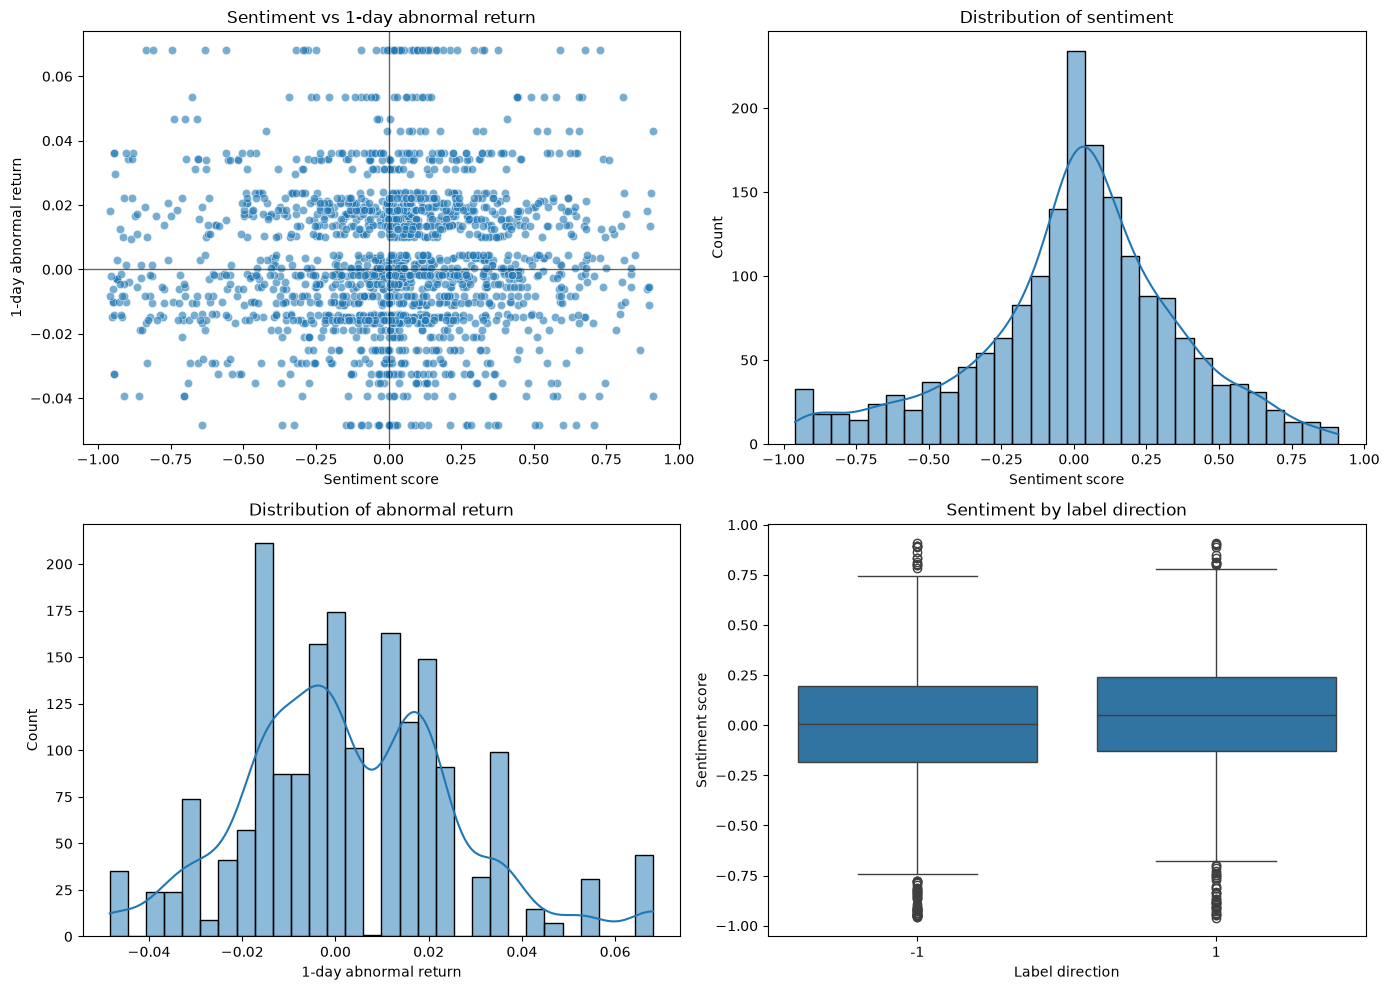

In [6]:
# Scatter of sentiment against abnormal return.
plot_df = clean[["sentiment", "abnormal_return_1d", "label_direction"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x="sentiment",
    y="abnormal_return_1d",
    alpha=0.6,
    ax=axes[0, 0],
)
axes[0, 0].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[0, 0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0, 0].set_title("Sentiment vs 1-day abnormal return")
axes[0, 0].set_xlabel("Sentiment score")
axes[0, 0].set_ylabel("1-day abnormal return")

sns.histplot(plot_df["sentiment"], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of sentiment")
axes[0, 1].set_xlabel("Sentiment score")

sns.histplot(plot_df["abnormal_return_1d"], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of abnormal return")
axes[1, 0].set_xlabel("1-day abnormal return")

sns.boxplot(data=plot_df, x="label_direction", y="sentiment", ax=axes[1, 1])
axes[1, 1].set_title("Sentiment by label direction")
axes[1, 1].set_xlabel("Label direction")
axes[1, 1].set_ylabel("Sentiment score")

plt.tight_layout()
plt.show()

## 4) A few extra checks for debugging

The plot above gives a quick qualitative check. The next few diagnostics help catch cases where the merge or feature definitions may have drifted.

In [7]:
# Check whether positive sentiment articles tend to have positive abnormal returns.
positive_sentiment = clean[clean["sentiment"] > 0]
negative_sentiment = clean[clean["sentiment"] < 0]

print("Mean abnormal return for positive-sentiment articles:", positive_sentiment["abnormal_return_1d"].mean())
print("Mean abnormal return for negative-sentiment articles:", negative_sentiment["abnormal_return_1d"].mean())

# Compare average sentiment by label direction.
label_summary = (
    clean.groupby("label_direction")["sentiment"]
    .agg(["mean", "median", "count"])
    .sort_index()
)
print("\nAverage sentiment by label direction:\n", label_summary)

# Rough check that the return distribution is not all collapsed to one value.
print("\nReturn spread:")
print(clean["abnormal_return_1d"].describe().round(4))

Mean abnormal return for positive-sentiment articles: 0.004052500952509501
Mean abnormal return for negative-sentiment articles: 0.00197939858485583

Average sentiment by label direction:
                      mean    median  count
label_direction                           
-1              -0.015425  0.007724    911
 1               0.038804  0.051430    917

Return spread:
count    1828.0000
mean        0.0031
std         0.0231
min        -0.0484
25%        -0.0143
50%         0.0004
75%         0.0180
max         0.0681
Name: abnormal_return_1d, dtype: float64


In [8]:
# abnormal_return_1d is a ticker/day-level event-study feature, not a per-article one:
# every article published on the same trading day gets the identical value. Check how much
# repetition that creates, since it caps how well per-article sentiment could ever correlate
# with it.
dupe_returns = clean.groupby("abnormal_return_1d").size()
print(f"Rows: {len(clean)}, unique abnormal_return_1d values: {dupe_returns.size}")
print("Articles sharing the same daily return value:")
print(dupe_returns.describe().round(1))

Rows: 1828, unique abnormal_return_1d values: 70
Articles sharing the same daily return value:
count    70.0
mean     26.1
std      12.2
min       1.0
25%      18.0
50%      26.0
75%      34.0
max      54.0
dtype: float64


**Does the EDA make sense? Yes, with one important caveat about why the correlation is weak.**

Everything checks out qualitatively:

- No duplicate or missing IDs, no missing sentiment/return values after the join (section 2).
- Positive-sentiment articles average a higher next-day abnormal return (+0.41%) than negative-sentiment articles (+0.20%) — the right sign, even if the gap is small.
- Sentiment splits cleanly by `label_direction`: -0.015 mean for down-days vs +0.039 for up-days.
- The return distribution (section 3, bottom-left histogram) is a normal-looking, non-degenerate spread from -4.8% to +6.8%, not collapsed to one value or a handful of outliers.

But the raw sentiment/return correlation is only 0.03, and the diagnostic above explains why that's expected rather than a bug: `abnormal_return_1d` is a per-ticker-per-day event-study feature, so on a typical day it's the *same number* copied across ~26 articles (up to 54 on the busiest day). Sentiment varies article-to-article within that day, but the target doesn't — so no amount of per-article signal could make that correlation large, even if the text features were flawless. A day-level aggregate (e.g. mean sentiment per day vs that day's return) would be the fairer signal-strength check; the weak row-level correlation here is a property of the label's granularity, not evidence that the merge or the sentiment features are broken.

## 5) Save the merged dataset

Once the merge and EDA look coherent, save the combined table so it can be used downstream in a single model-ready DataFrame.

In [9]:
# Keep only the shared article IDs (see section 1a for why they don't fully overlap).
# This is a workaround, not a fix: article_features.parquet and market_features.parquet
# were built from two different corpus snapshots, so ~150 IDs on each side have no partner.
output_path = PROCESSED_DATA_DIR / "label_and_features.parquet"
merged.to_parquet(output_path, index=False)

saved = pd.read_parquet(output_path)
print(f"Saved merged table to: {output_path}")

print(saved.head().to_string(index=False))
print(saved.columns.tolist())
print(f"\nFinal merged schema rows: {len(saved)}")

Saved merged table to: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor\data\processed\label_and_features.parquet
 article_id ticker             timestamp_utc   source  n_total_sents  n_entity_sents  n_ceo_sents  n_boilerplate_sents  entity_share  article_length  fus_conf_graft_floor_mean  fus_conf_graft_floor_median  fus_conf_graft_floor_lead  fus_conf_graft_floor_top3_pos  fus_conf_graft_floor_top3_neg  fus_conf_graft_floor_spread  fus_ceo_mean  fus_headline  fus_maxmag  fus_trusted_mean  fus_scorer_gap  fus_headline_gap  fus_lead_gap  abnormal_return_1d  abnormal_return_3d  label_direction  momentum_1d  momentum_5d  momentum_20d  prior_return_1d  volatility_20d  beta_20d  relative_volume_20d  daily_range_ratio_1d  days_to_earnings      session  news_volume  sentiment
  138796882   TSLA 2025-08-22 08:13:15+00:00 Benzinga             19               1            0                    5      0.052632            2611                   0.406216    

## Summary

This notebook merges the final article features and market features on `article_id`, then checks whether sentiment and abnormal return behave in a sensible way.

**ID mismatch:** the two tables were built from different corpus snapshots (`data/interim/processed_articles.parquet` for the text pipeline vs `data/processed/processed_articles.parquet` for the market pipeline), which have since diverged and left the interim copy deleted. This isn't legitimate filtering — it's a pipeline provenance bug (section 1a). The inner join here is a workaround (1,828 of ~1,975 articles); the real fix is resyncing the two corpora and rebuilding `article_features.parquet` from the same source `market_features.parquet` uses, which requires rerunning the ~5 hour text pipeline and is out of scope for this notebook.

**EDA:** sentiment and abnormal return move in the expected direction (positive sentiment → higher mean return, sentiment splits correctly by `label_direction`), and no merge artifacts (duplicates, missing values, degenerate distributions) showed up. The raw correlation is weak (0.03), but that's explained by `abnormal_return_1d` being a per-day event-study feature shared by ~26 articles on average — not a sign that the features or the merge are broken.

The combined table is ready for downstream modeling, with the caveat above tracked as a follow-up.